In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

df = pd.read_csv("../data/raw/store-data-6aa6d7a3f171f140353680.csv")
df.head()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

In [ ]:
df.isnull().any()

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
df[df["Quantity"].isnull()]

In [ ]:
df["Unit Price"] = df["Sales"] / df["Quantity"]

In [ ]:
df.groupby("Product Name")["Unit Price"].mean() 

In [ ]:
df.groupby("Product Name")["Product ID"].unique()

In [ ]:
df.groupby("Product Name")["Product ID"].agg(lambda x: x.mode()[0])

In [ ]:
df["City"].value_counts()

In [ ]:
df["Category"].value_counts()

In [ ]:
df["Region"].value_counts()

In [ ]:
df["Sub-Category"].value_counts()

In [ ]:
category_check = df.groupby("Sub-Category")["Category"].nunique()
problem_subcats = category_check[category_check > 1].index

for sub in problem_subcats:
    print(sub, ":")
    print(df[df["Sub-Category"] == sub]["Category"].value_counts())
    print()

In [ ]:
df.groupby("State")["Region"].nunique().sort_values(ascending=False)

In [ ]:
df.groupby("Customer Name")["Customer ID"].nunique().sort_values(ascending=False)

In [ ]:
id_check = df.groupby("Customer ID")["Customer Name"].nunique()
problem_ids = id_check[id_check > 1].index

for cid in problem_ids:
    print(cid, ":")
    print(df[df["Customer ID"] == cid]["Customer Name"].value_counts())
    print()

In [ ]:
df.groupby("Product Name")["Product ID"].nunique().sort_values(ascending=False)

In [ ]:
name_check = df.groupby("Product Name")["Product ID"].nunique()
problem_names = name_check[name_check > 1].index

for name in problem_names:
    print(name, ":")
    print(df[df["Product Name"] == name]["Product ID"].value_counts())
    print()

In [ ]:
id_cols = ["Row ID", "Order ID", "Customer ID", "Product ID"]
string_cols = df.select_dtypes(include="object").columns.difference(id_cols)
print(string_cols.tolist())



In [ ]:
for col in string_cols:
    df[col] = df[col].str.strip().str.lower()

In [ ]:
df.groupby("Sub-Category")["Category"].nunique().sort_values(ascending=False)

In [ ]:
df.groupby("State")["Region"].nunique().sort_values(ascending=False)

In [ ]:
df.groupby("Product Name")["Product ID"].nunique().sort_values(ascending=False)

In [ ]:
df.groupby("Customer Name")["Customer ID"].nunique().sort_values(ascending=False)

In [ ]:
df.duplicated().sum()


In [ ]:
for col in ["Country", "Segment", "Ship Mode"]:
    print(col, ":", df[col].unique())

In [ ]:
typo_map = {
        "consumerr": "consumer",
        "corporrate": "corporate",
        "home ofice": "home office",
    }
df["Segment"] = df["Segment"].replace(typo_map)

In [ ]:
invalid_customers = df["Customer Name"].isna()

customer_name_by_id = df.groupby("Customer ID")["Customer Name"].agg(lambda x:x.mode())

df.loc[invalid_customers, "Customer Name"] = df.loc[invalid_customers, "Customer ID"].map(customer_name_by_id)
customer_name_by_id

In [ ]:
    
df.isnull().sum()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', errors='coerce')

df['Ship Date'] = pd.to_datetime(df['Ship Date'] , format='mixed' , errors='coerce')



In [ ]:
invalid = df["Ship Date"] < df["Order Date"]
df.loc[invalid, "Ship Date"] = pd.NaT

In [ ]:
mask = (
    (df["Ship Date"] < df["Order Date"]) | (df["Ship Date"].isna())
    )
df_invalid_dates = df[mask]

len(df_invalid_dates)

In [ ]:

for col in ["Ship Date", "Ship Mode"]:
        mode_by_order = df.groupby("Order ID")[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
        df[col] =df[col].fillna(df['Order ID'].map(mode_by_order))
        

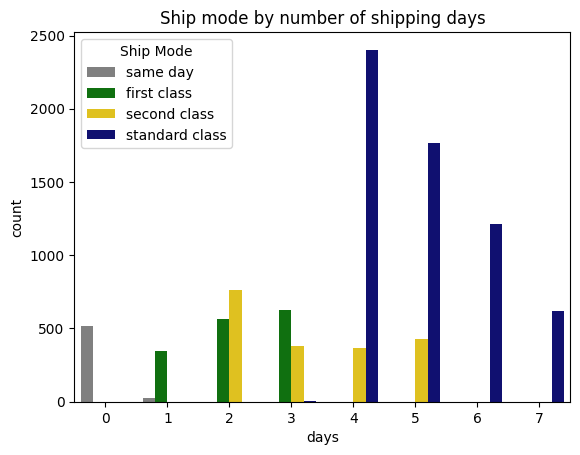

In [63]:
known = df.dropna(subset=["Order Date", "Ship Date", "Ship Mode"]).copy()
known["days"] = (known["Ship Date"] - known["Order Date"]).dt.days
known = known[known["days"] >= 0]

order = ["same day", "first class", "second class", "standard class"]

sns.countplot(data=known, x="days", hue="Ship Mode", hue_order=order,palette=["gray", "green", "gold", "navy"])
plt.title("Ship mode by number of shipping days")
plt.show()

In [ ]:
def shipping_days_per_shipping_mode(mode):
    days_by_mode = {"same day": 0, "first class": 2, "second class": 3, "standard class": 5}
    return days_by_mode.get(mode)

def shipping_mode_per_shipping_days(days):
    if pd.isna(days) or days < 0:
            return None
    mode_by_days = {0: "same day", 1: "first class", 2: "second class", 3: "first class",
                    4: "standard class", 5: "standard class", 6: "standard class", 7: "standard class"}
    return mode_by_days.get(days)

In [ ]:
missing = df["Ship Date"].isna() & df["Ship Mode"].notna()
days = df.loc[missing, "Ship Mode"].map(shipping_days_per_shipping_mode)
df.loc[missing, "Ship Date"] = df.loc[missing, "Order Date"] + pd.to_timedelta(days, unit="D")

In [ ]:
missing = df["Ship Mode"].isna() & df["Ship Date"].notna()
days = (df.loc[missing, "Ship Date"] - df.loc[missing, "Order Date"]).dt.days
df.loc[missing, "Ship Mode"] = days.map(shipping_mode_per_shipping_days)

In [ ]:
df["Postal Code"].sample(10)

In [ ]:
df["Postal Code"].str.len().value_counts()

In [ ]:
df["Postal Code"] = df["Postal Code"].str.split(".").str[0]
df["Postal Code"] = df["Postal Code"].str.zfill(5)

In [ ]:
known_Postal = df.groupby(["City"])["Postal Code"].count()
known_Postal[known_Postal==0]

In [ ]:
df[["Quantity", "Sales"]].isna().sum()

In [ ]:
(df["Quantity"].isna() & df["Sales"].isna()).sum()

In [ ]:
df["Quantity"].value_counts().sort_index()

In [ ]:
df["Sales"].describe()
df["Sales"].sort_values(ascending=False).head(10)

In [ ]:
df[df["Sales"] > 20000][["Product Name", "Quantity", "Discount", "Sales", "Profit"]]

In [ ]:
df = df.copy()
df["Unit Price"] = (df["Sales"] / (df["Quantity"] * (1 - df["Discount"]))).round(2)
price_by_product = df.groupby("Product ID")["Unit Price"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)

In [ ]:
invalid_sales = df["Sales"] == 1131924.0
invalid_quantity = df["Quantity"] < 0
invalid_discount = (df["Discount"] < 0) | (df["Discount"] > 1)

df = df[~(invalid_sales | invalid_quantity | invalid_discount)]

In [ ]:
df.isna().sum()


In [ ]:
df["Postal Code"] = df["Postal Code"].str.split(".").str[0]
df["Postal Code"] = df["Postal Code"].str.zfill(5)

In [ ]:
mode_by_city = df.groupby("City")["Postal Code"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
df["Postal Code"] = df["Postal Code"].fillna(df["City"].map(mode_by_city))

In [ ]:
df["Profit"].dtype
df["Profit"].isna().sum()
df["Profit"].describe()

In [ ]:
(df["Profit"] > 0).sum()

In [ ]:
(df["Profit"] < 0).sum()

In [ ]:
(df["Profit"] == 0).sum()

In [ ]:
df["Profit"].value_counts().head(10)

In [ ]:
df[df["Profit"] == 0][["Product Name", "Quantity", "Discount", "Sales", "Profit"]]